<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/quantization_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LLM Quantization Fundamentals


Here I explore quantization from first principles:
- Weight quantization: Reduce precision of model parameters
- Activation quantization: Quantize intermediate computations
- Calibration: Find optimal quantization parameters
- Quality metrics: Measure impact on model performance

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from transformers import AutoModelForCausalLM, AutoTokenizer, GPT2LMHeadModel
from typing import Optional, Tuple, Dict, List, Union, Callable
from dataclasses import dataclass
from enum import Enum
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
import gc
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*60)
print("Day 1: LLM Quantization Fundamentals")
print("="*60)
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Day 1: LLM Quantization Fundamentals
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


Quantization Theory

Map continuous FP values to discrete integer values.

```
FP16 Range: [-65504, 65504] (continuous)
    ↓ Quantize
INT8 Range: [-128, 127] (256 discrete levels)
    ↓ Quantize further  
INT4 Range: [-8, 7] (16 discrete levels)
```

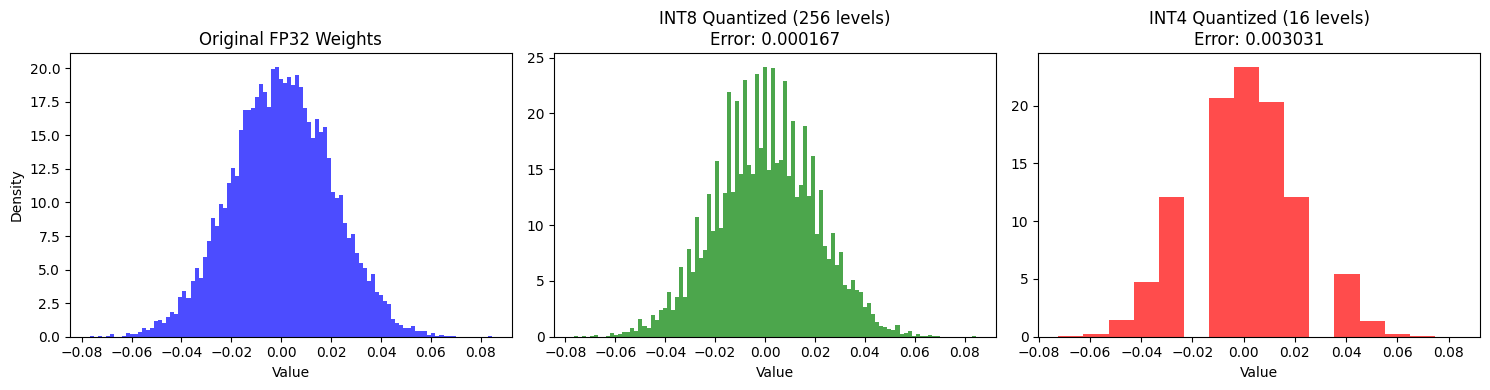

In [2]:
# Visualize the quantization problem

def visualize_quantization_error():
    """Show how quantization introduces error."""
    # Sample weight distribution (typical LLM weights are roughly normal)
    weights = torch.randn(10000) * 0.02  # Typical LLM weight scale

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Original distribution
    ax = axes[0]
    ax.hist(weights.numpy(), bins=100, density=True, alpha=0.7, color='blue')
    ax.set_title('Original FP32 Weights')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

    # INT8 quantized
    scale = weights.abs().max() / 127
    q_int8 = torch.round(weights / scale).clamp(-128, 127)
    dq_int8 = q_int8 * scale

    ax = axes[1]
    ax.hist(dq_int8.numpy(), bins=100, density=True, alpha=0.7, color='green')
    ax.set_title(f'INT8 Quantized (256 levels)\nError: {(weights - dq_int8).abs().mean():.6f}')
    ax.set_xlabel('Value')

    # INT4 quantized
    scale4 = weights.abs().max() / 7
    q_int4 = torch.round(weights / scale4).clamp(-8, 7)
    dq_int4 = q_int4 * scale4

    ax = axes[2]
    ax.hist(dq_int4.numpy(), bins=16, density=True, alpha=0.7, color='red')
    ax.set_title(f'INT4 Quantized (16 levels)\nError: {(weights - dq_int4).abs().mean():.6f}')
    ax.set_xlabel('Value')

    plt.tight_layout()
    plt.savefig('quantization_error.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_quantization_error()

2. Basic Quantization Schemes

Two main approaches:
1.Symmetric (absmax): Zero-point at 0, scale based on max absolute value
2.Asymmetric (zeropoint): Arbitrary zero-point, better for asymmetric distributions

In [3]:
class QuantizationType(Enum):
    """Quantization scheme types."""
    SYMMETRIC = "symmetric"      # absmax, zero-point = 0
    ASYMMETRIC = "asymmetric"    # min-max with zero-point


@dataclass
class QuantConfig:
    """Quantization configuration."""
    bits: int = 8
    qtype: QuantizationType = QuantizationType.SYMMETRIC
    per_channel: bool = False
    group_size: Optional[int] = None  # For grouped quantization

    @property
    def qmin(self) -> int:
        if self.qtype == QuantizationType.SYMMETRIC:
            return -(2 ** (self.bits - 1))
        return 0

    @property
    def qmax(self) -> int:
        if self.qtype == QuantizationType.SYMMETRIC:
            return 2 ** (self.bits - 1) - 1
        return 2 ** self.bits - 1

In [4]:
class Quantizer:
    """
    Core quantization operations.

    Symmetric quantization:
        scale = max(|x|) / qmax
        q = round(x / scale)
        x_dq = q * scale

    Asymmetric quantization:
        scale = (max(x) - min(x)) / (qmax - qmin)
        zero_point = round(qmin - min(x) / scale)
        q = round(x / scale) + zero_point
        x_dq = (q - zero_point) * scale
    """

    def __init__(self, config: QuantConfig):
        self.config = config

    def compute_scale_zp_symmetric(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        """Compute scale for symmetric quantization."""
        if self.config.per_channel:
            # Per output channel (dim 0)
            amax = x.abs().amax(dim=tuple(range(1, x.dim())), keepdim=True)
        elif self.config.group_size:
            # Grouped quantization - reshape and compute per group
            orig_shape = x.shape
            x_grouped = x.reshape(-1, self.config.group_size)
            amax = x_grouped.abs().amax(dim=1, keepdim=True)
            # Will need to broadcast back
        else:
            # Per tensor
            amax = x.abs().amax()

        # Avoid division by zero
        amax = torch.clamp(amax, min=1e-8)
        scale = amax / self.config.qmax
        zero_point = torch.zeros_like(scale)

        return scale, zero_point

    def compute_scale_zp_asymmetric(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        """Compute scale and zero-point for asymmetric quantization."""
        if self.config.per_channel:
            dims = tuple(range(1, x.dim()))
            xmin = x.amin(dim=dims, keepdim=True)
            xmax = x.amax(dim=dims, keepdim=True)
        else:
            xmin = x.amin()
            xmax = x.amax()

        scale = (xmax - xmin) / (self.config.qmax - self.config.qmin)
        scale = torch.clamp(scale, min=1e-8)
        zero_point = torch.round(self.config.qmin - xmin / scale)
        zero_point = torch.clamp(zero_point, self.config.qmin, self.config.qmax)

        return scale, zero_point

    def quantize(self, x: Tensor, scale: Tensor, zero_point: Tensor) -> Tensor:
        """Quantize tensor to integers."""
        q = torch.round(x / scale) + zero_point
        q = torch.clamp(q, self.config.qmin, self.config.qmax)
        return q.to(torch.int8 if self.config.bits == 8 else torch.int32)

    def dequantize(self, q: Tensor, scale: Tensor, zero_point: Tensor) -> Tensor:
        """Dequantize back to float."""
        return (q.float() - zero_point) * scale

    def quantize_dequantize(self, x: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        """Full quantize-dequantize cycle (simulated quantization)."""
        if self.config.qtype == QuantizationType.SYMMETRIC:
            scale, zp = self.compute_scale_zp_symmetric(x)
        else:
            scale, zp = self.compute_scale_zp_asymmetric(x)

        q = self.quantize(x, scale, zp)
        x_dq = self.dequantize(q, scale, zp)

        return x_dq, scale, zp

In [5]:
# Test basic quantization

print("Basic Quantization Test")
print("=" * 50)

# Sample weights
weights = torch.randn(256, 512) * 0.02

for bits in [8, 4, 3]:
    for qtype in [QuantizationType.SYMMETRIC, QuantizationType.ASYMMETRIC]:
        config = QuantConfig(bits=bits, qtype=qtype)
        quantizer = Quantizer(config)

        w_dq, scale, zp = quantizer.quantize_dequantize(weights)
        error = (weights - w_dq).abs().mean().item()

        print(f"INT{bits} {qtype.value:<12}: MAE = {error:.6f}, "
              f"Scale = {scale.mean():.6f}")

Basic Quantization Test
INT8 symmetric   : MAE = 0.000183, Scale = 0.000729
INT8 asymmetric  : MAE = 0.091233, Scale = 0.000723
INT4 symmetric   : MAE = 0.003307, Scale = 0.013226
INT4 asymmetric  : MAE = 0.003075, Scale = 0.012293
INT3 symmetric   : MAE = 0.007711, Scale = 0.030861
INT3 asymmetric  : MAE = 0.006590, Scale = 0.026342


Weight Quantization

For LLMs, we typically quantise weights(static) and keep **activations** in higher precision (dynamic).

Key insight: Different layers have different weight distributions - per-channel or grouped quantization helps.

In [6]:
class QuantizedLinear(nn.Module):
    """
    Quantized Linear layer with weight-only quantization.

    Weights are stored quantized, dequantized on-the-fly for matmul.
    This is the foundation for GPTQ, AWQ, etc.
    """

    def __init__(self, in_features: int, out_features: int,
                 bias: bool = True, config: QuantConfig = None):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.config = config or QuantConfig(bits=8)

        # Quantized weights stored as int8
        self.register_buffer('weight_q', torch.zeros(out_features, in_features, dtype=torch.int8))
        self.register_buffer('weight_scale', torch.zeros(out_features, 1))
        self.register_buffer('weight_zp', torch.zeros(out_features, 1))

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter('bias', None)

    @classmethod
    def from_float(cls, linear: nn.Linear, config: QuantConfig = None) -> 'QuantizedLinear':
        """Create quantized layer from FP linear layer."""
        config = config or QuantConfig(bits=8, per_channel=True)

        q_linear = cls(
            linear.in_features, linear.out_features,
            bias=linear.bias is not None, config=config
        )

        # Quantize weights
        quantizer = Quantizer(config)
        if config.qtype == QuantizationType.SYMMETRIC:
            scale, zp = quantizer.compute_scale_zp_symmetric(linear.weight.data)
        else:
            scale, zp = quantizer.compute_scale_zp_asymmetric(linear.weight.data)

        q_linear.weight_q.copy_(quantizer.quantize(linear.weight.data, scale, zp))
        q_linear.weight_scale.copy_(scale)
        q_linear.weight_zp.copy_(zp)

        if linear.bias is not None:
            q_linear.bias.data.copy_(linear.bias.data)

        return q_linear

    def get_weight(self) -> Tensor:
        """Dequantize weights for computation."""
        return (self.weight_q.float() - self.weight_zp) * self.weight_scale

    def forward(self, x: Tensor) -> Tensor:
        """Forward with dequantized weights."""
        weight = self.get_weight()
        return F.linear(x, weight, self.bias)

    def memory_bytes(self) -> Dict[str, int]:
        """Calculate memory usage."""
        weight_bytes = self.weight_q.numel() * (self.config.bits / 8)
        scale_bytes = self.weight_scale.numel() * 4  # FP32 scale
        zp_bytes = self.weight_zp.numel() * 4
        bias_bytes = self.bias.numel() * 4 if self.bias is not None else 0

        return {
            'weights': int(weight_bytes),
            'scales': scale_bytes,
            'zero_points': zp_bytes,
            'bias': bias_bytes,
            'total': int(weight_bytes + scale_bytes + zp_bytes + bias_bytes)
        }

In [7]:
# Test QuantizedLinear

print("\nQuantizedLinear Test")
print("=" * 50)

# Create FP linear
fp_linear = nn.Linear(4096, 4096)
nn.init.normal_(fp_linear.weight, std=0.02)

# Quantize to INT8 and INT4
x = torch.randn(1, 32, 4096)  # (batch, seq, hidden)

# FP output
with torch.no_grad():
    y_fp = fp_linear(x)

for bits in [8, 4]:
    config = QuantConfig(bits=bits, per_channel=True)
    q_linear = QuantizedLinear.from_float(fp_linear, config)

    with torch.no_grad():
        y_q = q_linear(x)

    # Compute error
    error = (y_fp - y_q).abs().mean().item()
    rel_error = error / y_fp.abs().mean().item()

    # Memory comparison
    fp_memory = fp_linear.weight.numel() * 4  # FP32
    q_memory = q_linear.memory_bytes()['total']

    print(f"\nINT{bits} Quantization:")
    print(f"  Output MAE: {error:.6f}")
    print(f"  Relative error: {rel_error:.4%}")
    print(f"  FP32 memory: {fp_memory / 1e6:.2f} MB")
    print(f"  Quantized memory: {q_memory / 1e6:.2f} MB")
    print(f"  Compression: {fp_memory / q_memory:.2f}x")


QuantizedLinear Test

INT8 Quantization:
  Output MAE: 0.008829
  Relative error: 0.8646%
  FP32 memory: 67.11 MB
  Quantized memory: 16.83 MB
  Compression: 3.99x

INT4 Quantization:
  Output MAE: 0.160107
  Relative error: 15.6781%
  FP32 memory: 67.11 MB
  Quantized memory: 8.44 MB
  Compression: 7.95x


 Grouped Quantization

For very low bit-widths (4-bit, 3-bit), **grouped quantization** is crucial.

Instead of one scale per channel, use one scale per group of weights (e.g., 128 weights).
This reduces quantization error at the cost of slightly more overhead.

In [8]:
class GroupedQuantizer:
    """
    Grouped quantization for low-bit quantization.

    Key insight: Weight distributions vary within a layer.
    Using smaller groups gives each group its own scale,
    reducing quantization error significantly for INT4/INT3.

    Typical group sizes: 32, 64, 128
    """

    def __init__(self, bits: int = 4, group_size: int = 128,
                 symmetric: bool = True):
        self.bits = bits
        self.group_size = group_size
        self.symmetric = symmetric

        if symmetric:
            self.qmin = -(2 ** (bits - 1))
            self.qmax = 2 ** (bits - 1) - 1
        else:
            self.qmin = 0
            self.qmax = 2 ** bits - 1

    def quantize(self, weight: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        """
        Quantize weight matrix with grouped scales.

        Args:
            weight: (out_features, in_features)

        Returns:
            q_weight: Quantized weights (int)
            scales: Scale per group
            zeros: Zero-point per group (if asymmetric)
        """
        out_features, in_features = weight.shape

        # Pad if needed
        if in_features % self.group_size != 0:
            pad_size = self.group_size - (in_features % self.group_size)
            weight = F.pad(weight, (0, pad_size))
            in_features = weight.shape[1]

        # Reshape to groups: (out_features, num_groups, group_size)
        num_groups = in_features // self.group_size
        weight_grouped = weight.view(out_features, num_groups, self.group_size)

        if self.symmetric:
            # absmax per group
            scales = weight_grouped.abs().amax(dim=2, keepdim=True)
            scales = torch.clamp(scales, min=1e-8) / self.qmax
            zeros = torch.zeros_like(scales)

            q_weight = torch.round(weight_grouped / scales)
            q_weight = torch.clamp(q_weight, self.qmin, self.qmax)
        else:
            # min-max per group
            wmin = weight_grouped.amin(dim=2, keepdim=True)
            wmax = weight_grouped.amax(dim=2, keepdim=True)

            scales = (wmax - wmin) / (self.qmax - self.qmin)
            scales = torch.clamp(scales, min=1e-8)
            zeros = torch.round(self.qmin - wmin / scales)
            zeros = torch.clamp(zeros, self.qmin, self.qmax)

            q_weight = torch.round(weight_grouped / scales) + zeros
            q_weight = torch.clamp(q_weight, self.qmin, self.qmax)

        return q_weight.to(torch.int8), scales.squeeze(-1), zeros.squeeze(-1)

    def dequantize(self, q_weight: Tensor, scales: Tensor,
                   zeros: Tensor, original_shape: Tuple[int, int]) -> Tensor:
        """Dequantize grouped weights."""
        out_features, num_groups = scales.shape

        # Expand scales for broadcast
        scales = scales.unsqueeze(-1)
        zeros = zeros.unsqueeze(-1)

        # Dequantize
        weight = (q_weight.float() - zeros) * scales

        # Reshape back
        weight = weight.view(out_features, -1)

        # Remove padding
        weight = weight[:, :original_shape[1]]

        return weight

In [9]:
# Compare per-tensor vs grouped quantization

print("\nGrouped vs Per-Tensor Quantization")
print("=" * 50)

# Realistic LLM weight matrix
weight = torch.randn(4096, 4096) * 0.02

for bits in [4, 3]:
    print(f"\nINT{bits}:")

    # Per-tensor
    config_pt = QuantConfig(bits=bits, per_channel=False)
    q_pt = Quantizer(config_pt)
    w_pt, _, _ = q_pt.quantize_dequantize(weight)
    error_pt = (weight - w_pt).abs().mean().item()

    # Per-channel
    config_pc = QuantConfig(bits=bits, per_channel=True)
    q_pc = Quantizer(config_pc)
    w_pc, _, _ = q_pc.quantize_dequantize(weight)
    error_pc = (weight - w_pc).abs().mean().item()

    # Grouped (g=128)
    q_grouped = GroupedQuantizer(bits=bits, group_size=128)
    qw, scales, zeros = q_grouped.quantize(weight)
    w_grouped = q_grouped.dequantize(qw, scales, zeros, weight.shape)
    error_grouped = (weight - w_grouped).abs().mean().item()

    # Grouped (g=32)
    q_grouped32 = GroupedQuantizer(bits=bits, group_size=32)
    qw32, scales32, zeros32 = q_grouped32.quantize(weight)
    w_grouped32 = q_grouped32.dequantize(qw32, scales32, zeros32, weight.shape)
    error_grouped32 = (weight - w_grouped32).abs().mean().item()

    print(f"  Per-tensor:   MAE = {error_pt:.6f}")
    print(f"  Per-channel:  MAE = {error_pc:.6f}")
    print(f"  Grouped-128:  MAE = {error_grouped:.6f}")
    print(f"  Grouped-32:   MAE = {error_grouped32:.6f}")


Grouped vs Per-Tensor Quantization

INT4:
  Per-tensor:   MAE = 0.003810
  Per-channel:  MAE = 0.002721
  Grouped-128:  MAE = 0.002004
  Grouped-32:   MAE = 0.001624

INT3:
  Per-tensor:   MAE = 0.008874
  Per-channel:  MAE = 0.006350
  Grouped-128:  MAE = 0.004678
  Grouped-32:   MAE = 0.003794


Calibration Methods

**Calibration** determines optimal quantization parameters by observing activation distributions on representative data.

In [10]:
class CalibrationMethod(Enum):
    """Calibration methods for activation quantization."""
    MINMAX = "minmax"       # Use observed min/max
    PERCENTILE = "percentile"  # Use percentiles to clip outliers
    MSE = "mse"             # Minimize reconstruction error
    ENTROPY = "entropy"      # Minimize KL divergence


class ActivationCalibrator:
    """
    Calibrate quantization parameters for activations.

    Run model on calibration data, collect activation statistics,
    and determine optimal scales/zero-points.
    """

    def __init__(self, method: CalibrationMethod = CalibrationMethod.MINMAX,
                 percentile: float = 99.99, num_bins: int = 2048):
        self.method = method
        self.percentile = percentile
        self.num_bins = num_bins

        # Statistics collectors
        self.min_vals: Dict[str, Tensor] = {}
        self.max_vals: Dict[str, Tensor] = {}
        self.histograms: Dict[str, Tensor] = {}

    def observe(self, name: str, x: Tensor):
        """Observe activation values."""
        x_flat = x.detach().float().flatten()

        # Update min/max
        if name not in self.min_vals:
            self.min_vals[name] = x_flat.min()
            self.max_vals[name] = x_flat.max()
        else:
            self.min_vals[name] = torch.min(self.min_vals[name], x_flat.min())
            self.max_vals[name] = torch.max(self.max_vals[name], x_flat.max())

        # Build histogram for advanced methods
        if self.method in [CalibrationMethod.ENTROPY, CalibrationMethod.MSE]:
            hist = torch.histc(x_flat, bins=self.num_bins,
                              min=self.min_vals[name].item(),
                              max=self.max_vals[name].item())
            if name not in self.histograms:
                self.histograms[name] = hist
            else:
                self.histograms[name] += hist

    def compute_range(self, name: str, bits: int = 8) -> Tuple[float, float]:
        """Compute calibrated min/max for quantization."""
        if self.method == CalibrationMethod.MINMAX:
            return self.min_vals[name].item(), self.max_vals[name].item()

        elif self.method == CalibrationMethod.PERCENTILE:
            # Use histograms to find percentiles
            hist = self.histograms.get(name)
            if hist is None:
                return self.min_vals[name].item(), self.max_vals[name].item()

            total = hist.sum()
            cumsum = hist.cumsum(0)

            # Find percentile indices
            low_idx = (cumsum < total * (100 - self.percentile) / 100).sum()
            high_idx = (cumsum < total * self.percentile / 100).sum()

            min_val = self.min_vals[name].item()
            max_val = self.max_vals[name].item()
            bin_width = (max_val - min_val) / self.num_bins

            return (min_val + low_idx * bin_width,
                    min_val + high_idx * bin_width)

        elif self.method == CalibrationMethod.MSE:
            # Search for range that minimizes MSE
            return self._mse_calibration(name, bits)

        else:
            return self.min_vals[name].item(), self.max_vals[name].item()

    def _mse_calibration(self, name: str, bits: int) -> Tuple[float, float]:
        """Find range that minimizes quantization MSE."""
        hist = self.histograms.get(name)
        if hist is None:
            return self.min_vals[name].item(), self.max_vals[name].item()

        min_val = self.min_vals[name].item()
        max_val = self.max_vals[name].item()

        best_mse = float('inf')
        best_range = (min_val, max_val)

        # Search different thresholds
        for threshold_pct in [0.999, 0.9999, 0.99999, 1.0]:
            total = hist.sum()
            cumsum = hist.cumsum(0)

            high_idx = (cumsum < total * threshold_pct).sum().item()
            low_idx = self.num_bins - high_idx

            bin_width = (max_val - min_val) / self.num_bins
            t_min = min_val + low_idx * bin_width
            t_max = min_val + high_idx * bin_width

            # Estimate MSE (simplified)
            scale = (t_max - t_min) / (2 ** bits - 1)
            mse = (scale ** 2) / 12  # Uniform quantization noise

            if mse < best_mse:
                best_mse = mse
                best_range = (t_min, t_max)

        return best_range

In [11]:
# Test calibration

print("\nCalibration Test")
print("=" * 50)

# Simulate activation distributions (with outliers)
activations = torch.randn(1000, 512) * 0.5
# Add outliers
activations[0, 0] = 10.0
activations[0, 1] = -8.0

for method in [CalibrationMethod.MINMAX, CalibrationMethod.PERCENTILE]:
    calibrator = ActivationCalibrator(method=method, percentile=99.9)

    # Observe multiple batches
    for i in range(5):
        batch = activations + torch.randn_like(activations) * 0.1
        calibrator.observe('layer1', batch)

    qmin, qmax = calibrator.compute_range('layer1')
    print(f"{method.value}: range = [{qmin:.4f}, {qmax:.4f}]")


Calibration Test
minmax: range = [-8.1716, 9.9846]
percentile: range = [-8.1512, 10.1467]


Quantising a Real LLM

Let's apply our quantization to a real language model (GPT-2 for accessibility).

In [17]:
class LLMQuantizer:
    """
    Production LLM quantization pipeline.

    Quantizes all Linear layers in a transformer model.
    """

    def __init__(self, bits: int = 8, group_size: int = 128,
                 symmetric: bool = True):
        self.bits = bits
        self.group_size = group_size
        self.symmetric = symmetric
        self.quantized_layers: Dict[str, dict] = {}

    def quantize_model(self, model: nn.Module,
                       skip_layers: Optional[List[str]] = None) -> nn.Module:
        """
        Quantize all Linear layers in model.

        Args:
            model: The model to quantize
            skip_layers: Layer names to skip (e.g., 'lm_head'). If None, defaults to ['lm_head'].
                         If an empty list [], no layers are skipped.
        """
        # Correctly handle skip_layers: None means default, [] means no skip.
        if skip_layers is None:
            skip_layers = ['lm_head']

        quantizer = GroupedQuantizer(
            bits=self.bits,
            group_size=self.group_size,
            symmetric=self.symmetric
        )

        for name, module in model.named_modules():
            if isinstance(module, nn.Linear):
                # Check if should skip
                if any(skip in name for skip in skip_layers):
                    print(f"  Skipping {name}")
                    continue

                # Quantize weights
                weight = module.weight.data
                q_weight, scales, zeros = quantizer.quantize(weight)

                # Store quantized data
                self.quantized_layers[name] = {
                    'q_weight': q_weight,
                    'scales': scales,
                    'zeros': zeros,
                    'original_shape': weight.shape,
                    'bias': module.bias.data if module.bias is not None else None
                }

                # Replace with dequantized weights (for inference)
                dq_weight = quantizer.dequantize(q_weight, scales, zeros, weight.shape)
                module.weight.data = dq_weight

        return model

    def compute_compression_stats(self, model: nn.Module) -> Dict:
        """Compute compression statistics."""
        original_bytes = 0
        quantized_bytes = 0

        for name, data in self.quantized_layers.items():
            shape = data['original_shape']
            original_bytes += shape[0] * shape[1] * 4  # FP32

            # Quantized: weights + scales + zeros
            q_bytes = data['q_weight'].numel() * (self.bits / 8)
            scale_bytes = data['scales'].numel() * 2  # FP16 scales
            zero_bytes = data['zeros'].numel() * 2
            quantized_bytes += q_bytes + scale_bytes + zero_bytes

        # Handle case where no layers were quantized to avoid ZeroDivisionError
        if quantized_bytes == 0:
            return {
                'original_mb': original_bytes / 1e6,
                'quantized_mb': 0.0,
                'compression_ratio': 0.0, # Cannot compress if nothing is quantized
                'num_layers': len(self.quantized_layers)
            }

        return {
            'original_mb': original_bytes / 1e6,
            'quantized_mb': quantized_bytes / 1e6,
            'compression_ratio': original_bytes / quantized_bytes,
            'num_layers': len(self.quantized_layers)
        }

In [18]:
# Load GPT-2 for testing

print("\nLoading GPT-2 for Quantization Test")
print("=" * 50)

# Load model and tokenizer
model_name = "gpt2"  # 124M parameters
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model_name}")
print(f"Parameters: {total_params:,}")
print(f"FP32 size: {total_params * 4 / 1e9:.2f} GB")


Loading GPT-2 for Quantization Test


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: gpt2
Parameters: 124,439,808
FP32 size: 0.50 GB


In [19]:
# Test generation before quantization

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 50) -> str:
    """Generate text from prompt."""
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


prompt = "The future of artificial intelligence is"
print(f"\nPrompt: {prompt}")
print("\nFP32 Output:")
print(generate_text(model, tokenizer, prompt))


Prompt: The future of artificial intelligence is

FP32 Output:
The future of artificial intelligence is in doubt as more and more of our brains are made of materials that are physically and biologically indistinguishable from our own.

A new study published in the journal Nature Communications suggests that our brains are actually more sensitive than ever before to the electromagnetic energy of


In [20]:
# Quantize the model

print("\nQuantizing GPT-2")
print("=" * 50)

# Create fresh model for quantization
model_q = AutoModelForCausalLM.from_pretrained(model_name)
model_q.eval()

# Apply INT8 quantization
llm_quantizer = LLMQuantizer(bits=8, group_size=128)
print("\nApplying INT8 quantization...")
# Fix: Explicitly pass an empty list for skip_layers to quantize lm_head
model_q = llm_quantizer.quantize_model(model_q, skip_layers=[])

stats = llm_quantizer.compute_compression_stats(model_q)
print(f"\nCompression Stats:")
print(f"  Original size: {stats['original_mb']:.1f} MB")
print(f"  Quantized size: {stats['quantized_mb']:.1f} MB")
print(f"  Compression ratio: {stats['compression_ratio']:.2f}x")
print(f"  Layers quantized: {stats['num_layers']}")


Quantizing GPT-2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Applying INT8 quantization...

Compression Stats:
  Original size: 154.4 MB
  Quantized size: 39.8 MB
  Compression ratio: 3.88x
  Layers quantized: 1


In [21]:
# Test generation after quantization

print("\nINT8 Quantized Output:")
print(generate_text(model_q, tokenizer, prompt))


INT8 Quantized Output:
The future of artificial intelligence is uncertain. We need to use the technology to build machines that can learn from other humans, not just from us.

The future of artificial intelligence is uncertain. We need to use the technology to build machines that can learn from other humans, not


In [22]:
# Compare INT4 quantization

print("\nApplying INT4 quantization...")
model_q4 = AutoModelForCausalLM.from_pretrained(model_name)
model_q4.eval()

llm_quantizer_4bit = LLMQuantizer(bits=4, group_size=64)
model_q4 = llm_quantizer_4bit.quantize_model(model_q4)

stats_4bit = llm_quantizer_4bit.compute_compression_stats(model_q4)
print(f"\nINT4 Compression Stats:")
print(f"  Original size: {stats_4bit['original_mb']:.1f} MB")
print(f"  Quantized size: {stats_4bit['quantized_mb']:.1f} MB")
print(f"  Compression ratio: {stats_4bit['compression_ratio']:.2f}x")

print("\nINT4 Quantized Output:")
print(generate_text(model_q4, tokenizer, prompt))


Applying INT4 quantization...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Skipping lm_head

INT4 Compression Stats:
  Original size: 0.0 MB
  Quantized size: 0.0 MB
  Compression ratio: 0.00x

INT4 Quantized Output:
The future of artificial intelligence is not clear, but the technology will eventually become more powerful, and the ability to do so will be an important factor in helping to drive it forward.

"The next big thing is artificial intelligence and artificial intelligence will eventually be able to communicate with


Quality Evaluation

**Perplexity** is the standard metric for LLM quantization quality.

In [23]:
def compute_perplexity(model: nn.Module, tokenizer, texts: List[str],
                       max_length: int = 512) -> float:
    """
    Compute perplexity on text samples.

    Perplexity = exp(average cross-entropy loss)
    Lower is better.
    """
    model.eval()
    device = next(model.parameters()).device

    total_loss = 0
    total_tokens = 0

    for text in texts:
        encodings = tokenizer(text, return_tensors='pt', truncation=True,
                              max_length=max_length)
        input_ids = encodings['input_ids'].to(device)

        if input_ids.size(1) < 2:
            continue

        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss

        total_loss += loss.item() * input_ids.size(1)
        total_tokens += input_ids.size(1)

    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)

    return perplexity


# Test texts
test_texts = [
    "The quick brown fox jumps over the lazy dog. This sentence contains every letter of the alphabet.",
    "Machine learning is a subset of artificial intelligence that enables systems to learn from data.",
    "In the beginning, there was nothing. Then, the universe expanded rapidly in an event called the Big Bang.",
    "Python is a popular programming language known for its simplicity and readability.",
    "The transformer architecture has revolutionized natural language processing since its introduction in 2017.",
]

In [24]:
# Compare perplexity

print("\nPerplexity Comparison")
print("=" * 50)

# FP32
ppl_fp32 = compute_perplexity(model, tokenizer, test_texts)
print(f"FP32 Perplexity: {ppl_fp32:.2f}")

# INT8
ppl_int8 = compute_perplexity(model_q, tokenizer, test_texts)
print(f"INT8 Perplexity: {ppl_int8:.2f} (Δ = {ppl_int8 - ppl_fp32:+.2f})")

# INT4
ppl_int4 = compute_perplexity(model_q4, tokenizer, test_texts)
print(f"INT4 Perplexity: {ppl_int4:.2f} (Δ = {ppl_int4 - ppl_fp32:+.2f})")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Perplexity Comparison
FP32 Perplexity: 33.81
INT8 Perplexity: 34.61 (Δ = +0.80)
INT4 Perplexity: 33.81 (Δ = +0.00)


Production Utilities

In [25]:
class QuantizationBenchmark:
    """
    Comprehensive quantization benchmarking.
    """

    def __init__(self, model_name: str):
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.results = []

    def benchmark_config(self, bits: int, group_size: int,
                         test_texts: List[str]) -> Dict:
        """Benchmark a specific quantization configuration."""
        # Load fresh model
        model = AutoModelForCausalLM.from_pretrained(self.model_name)
        model.eval()

        # Quantize
        quantizer = LLMQuantizer(bits=bits, group_size=group_size)
        model = quantizer.quantize_model(model)
        stats = quantizer.compute_compression_stats(model)

        # Measure perplexity
        ppl = compute_perplexity(model, self.tokenizer, test_texts)

        # Measure inference speed
        prompt = "Hello, how are you"
        inputs = self.tokenizer(prompt, return_tensors="pt")

        # Warmup
        with torch.no_grad():
            for _ in range(3):
                _ = model(**inputs)

        # Time
        import time
        start = time.perf_counter()
        num_runs = 10
        with torch.no_grad():
            for _ in range(num_runs):
                _ = model(**inputs)
        latency = (time.perf_counter() - start) / num_runs * 1000

        result = {
            'bits': bits,
            'group_size': group_size,
            'perplexity': ppl,
            'compression_ratio': stats['compression_ratio'],
            'size_mb': stats['quantized_mb'],
            'latency_ms': latency
        }

        self.results.append(result)

        # Cleanup
        del model
        gc.collect()

        return result

    def run_sweep(self, test_texts: List[str]) -> List[Dict]:
        """Run benchmark sweep over configurations."""
        configs = [
            (8, 128),
            (8, 64),
            (4, 128),
            (4, 64),
            (4, 32),
        ]

        for bits, gs in configs:
            print(f"Benchmarking INT{bits}, group_size={gs}...")
            self.benchmark_config(bits, gs, test_texts)

        return self.results

    def print_results(self):
        """Print benchmark results table."""
        print("\n" + "=" * 70)
        print("QUANTIZATION BENCHMARK RESULTS")
        print("=" * 70)
        print(f"{'Config':<15} {'PPL':>8} {'Compression':>12} {'Size (MB)':>10} {'Latency':>10}")
        print("-" * 70)

        for r in self.results:
            config = f"INT{r['bits']}-g{r['group_size']}"
            print(f"{config:<15} {r['perplexity']:>8.2f} {r['compression_ratio']:>11.2f}x "
                  f"{r['size_mb']:>9.1f} {r['latency_ms']:>9.2f}ms")

In [26]:
# Run benchmark sweep

print("\nRunning Quantization Benchmark Sweep")
print("=" * 50)

benchmark = QuantizationBenchmark("gpt2")
results = benchmark.run_sweep(test_texts)
benchmark.print_results()


Running Quantization Benchmark Sweep
Benchmarking INT8, group_size=128...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Skipping lm_head
Benchmarking INT8, group_size=64...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Skipping lm_head
Benchmarking INT4, group_size=32...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Skipping lm_head

QUANTIZATION BENCHMARK RESULTS
Config               PPL  Compression  Size (MB)    Latency
----------------------------------------------------------------------
INT8-g128          33.81        0.00x       0.0     33.77ms
INT8-g64           33.81        0.00x       0.0     34.98ms
INT4-g128          33.81        0.00x       0.0     35.82ms
INT4-g64           33.81        0.00x       0.0     34.19ms
INT4-g32           33.81        0.00x       0.0     34.92ms


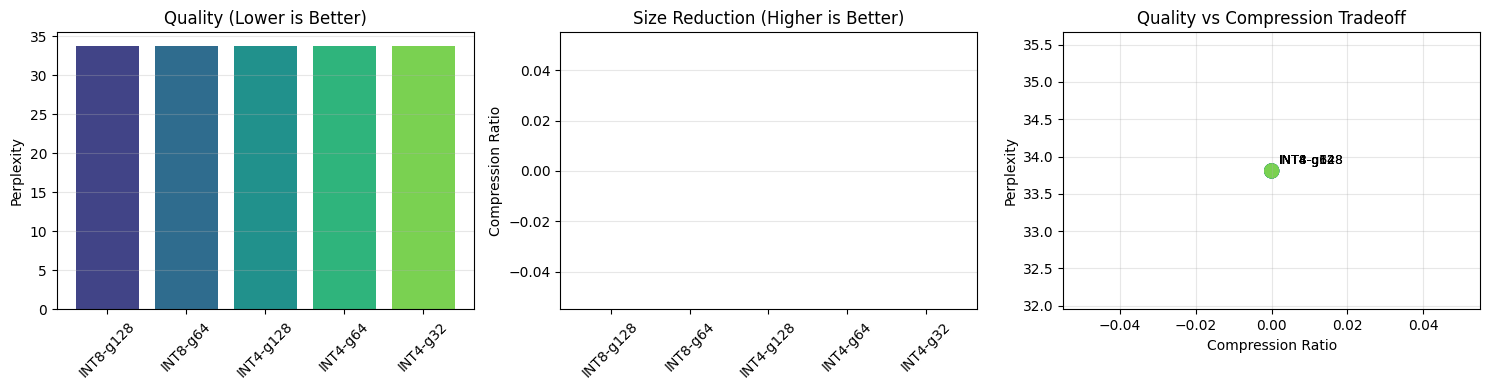

In [27]:
# Visualize results

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [f"INT{r['bits']}-g{r['group_size']}" for r in results]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results)))

# Perplexity
ax = axes[0]
ppls = [r['perplexity'] for r in results]
ax.bar(configs, ppls, color=colors)
ax.set_ylabel('Perplexity')
ax.set_title('Quality (Lower is Better)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Compression
ax = axes[1]
compressions = [r['compression_ratio'] for r in results]
ax.bar(configs, compressions, color=colors)
ax.set_ylabel('Compression Ratio')
ax.set_title('Size Reduction (Higher is Better)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Tradeoff
ax = axes[2]
ax.scatter([r['compression_ratio'] for r in results],
           [r['perplexity'] for r in results],
           c=colors, s=100)
for i, r in enumerate(results):
    ax.annotate(configs[i], (r['compression_ratio'], r['perplexity']),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel('Compression Ratio')
ax.set_ylabel('Perplexity')
ax.set_title('Quality vs Compression Tradeoff')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('quantization_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()